# Self-Organizing Map (SOM) — Kohonen Network

A Self-Organizing Map is an unsupervised competitive network that learns a
low-dimensional (usually 2-D) topological representation of high-dimensional
input data. It preserves the topology of the input space: similar inputs
map to nearby neurons on the grid.

**Key concepts:**
- **Best Matching Unit (BMU)** — the neuron whose weight vector is closest to the current input (the "winner").
- **Neighbourhood function** — neurons close to the BMU on the grid also update their weights, but to a lesser degree.
- **Learning rate & neighbourhood radius** both decay over time so that the map first organises globally, then fine-tunes locally.

**Example:** We train a 20×20 SOM on random 3-D RGB colour vectors and visualise how the map self-organises into smooth colour regions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

## 1. Hyperparameters

In [2]:
GRID_H, GRID_W = 20, 20          # SOM grid dimensions
INPUT_DIM      = 3                # RGB colour space
N_SAMPLES      = 1000             # training samples
N_EPOCHS       = 200              # passes over the data
INIT_LR        = 0.5              # initial learning rate
INIT_RADIUS    = max(GRID_H, GRID_W) / 2.0  # initial neighbourhood radius
TIME_CONST_LR  = N_EPOCHS / np.log(INIT_LR)
TIME_CONST_RAD = N_EPOCHS / np.log(INIT_RADIUS)

rng = np.random.default_rng(42)

print(f"Grid: {GRID_H}x{GRID_W}, Input dim: {INPUT_DIM}")
print(f"Epochs: {N_EPOCHS}, Initial LR: {INIT_LR}, Initial radius: {INIT_RADIUS:.1f}")

Grid: 20x20, Input dim: 3
Epochs: 200, Initial LR: 0.5, Initial radius: 10.0


## 2. Initialise Weight Vectors (random in [0,1])

In [3]:
weights = rng.random((GRID_H, GRID_W, INPUT_DIM))  # shape (20, 20, 3)

# Pre-compute grid coordinate matrix for neighbourhood calculations
grid_coords = np.array([[(i, j) for j in range(GRID_W)]
                         for i in range(GRID_H)])  # shape (20, 20, 2)

## 3. Generate Training Data — Random RGB Colours

In [4]:
data = rng.random((N_SAMPLES, INPUT_DIM))
print(f"Training data shape: {data.shape}")

Training data shape: (1000, 3)


## 4. SOM Helper Functions

In [5]:
def find_bmu(x: np.ndarray, weights: np.ndarray) -> tuple:
    """Return (row, col) index of the Best Matching Unit."""
    diff = weights - x  # broadcasting: (H, W, D) - (D,) → (H, W, D)
    dist_sq = np.sum(diff ** 2, axis=2)  # (H, W)
    bmu_idx = np.unravel_index(np.argmin(dist_sq), dist_sq.shape)
    return bmu_idx


def decay(initial: float, t: int, time_const: float) -> float:
    """Exponential decay schedule."""
    return initial * np.exp(-t / time_const)


def neighbourhood_influence(bmu: tuple, grid_coords: np.ndarray,
                             radius: float) -> np.ndarray:
    """
    Gaussian neighbourhood function.
    Returns an (H, W) matrix of influence values for every neuron.
    """
    bmu_coord = np.array(bmu)
    diff = grid_coords - bmu_coord  # (H, W, 2)
    dist_sq = np.sum(diff ** 2, axis=2)  # (H, W)
    return np.exp(-dist_sq / (2 * radius ** 2))  # (H, W)

## 5. Training Loop

In [6]:
print("Training SOM ...")

# Save snapshots for visualisation
snapshots = {}
snapshot_epochs = [0, 10, 50, 100, N_EPOCHS - 1]

for epoch in range(N_EPOCHS):
    # Shuffle data each epoch
    order = rng.permutation(N_SAMPLES)

    lr = decay(INIT_LR, epoch, TIME_CONST_LR)
    radius = decay(INIT_RADIUS, epoch, TIME_CONST_RAD)
    radius = max(radius, 1.0)  # keep a minimum radius of 1

    for idx in order:
        x = data[idx]
        bmu = find_bmu(x, weights)
        influence = neighbourhood_influence(bmu, grid_coords, radius)

        # Update weights: Δw = lr · h(bmu, j) · (x - w_j)
        weights += lr * influence[:, :, np.newaxis] * (x - weights)

    # Save snapshot
    if epoch in snapshot_epochs:
        snapshots[epoch] = weights.copy()

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"  Epoch {epoch + 1:>4}/{N_EPOCHS}  |  lr={lr:.4f}  |  radius={radius:.2f}")

print("Training complete!")

Training SOM ...
  Epoch    1/200  |  lr=0.5000  |  radius=10.00
  Epoch   50/200  |  lr=0.5925  |  radius=5.69
  Epoch  100/200  |  lr=0.7047  |  radius=3.20
  Epoch  150/200  |  lr=0.8380  |  radius=1.80
  Epoch  200/200  |  lr=0.9965  |  radius=1.01
Training complete!


## 6. Visualisation — Colour Map at Different Epochs

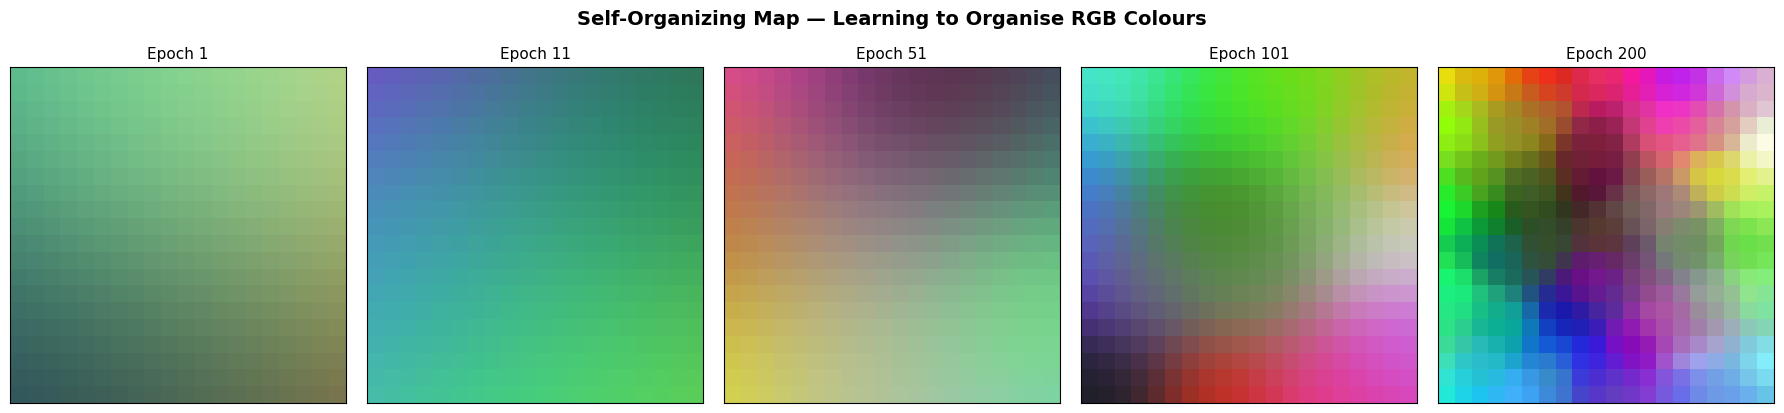

In [7]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4))
fig.suptitle("Self-Organizing Map — Learning to Organise RGB Colours",
             fontsize=14, fontweight="bold", y=1.02)

for ax, (ep, snap) in zip(axes, snapshots.items()):
    # Clip weights to [0, 1] for valid RGB display
    img = np.clip(snap, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Epoch {ep + 1}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 7. U-Matrix (Unified Distance Matrix)

The U-matrix shows the average Euclidean distance between each neuron
and its immediate neighbours. Valleys indicate clusters; ridges
indicate boundaries between clusters.

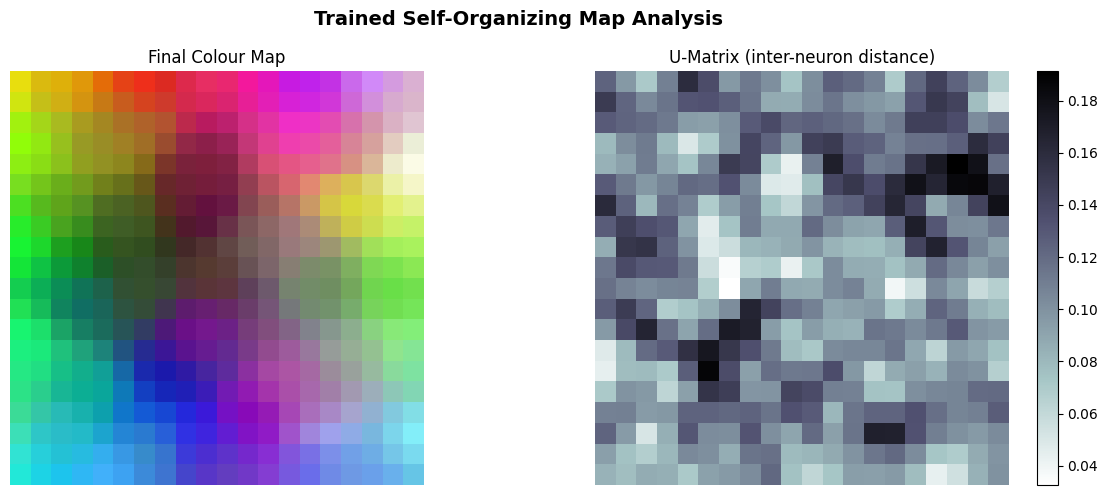

In [8]:
def compute_umatrix(weights: np.ndarray) -> np.ndarray:
    """Compute the U-matrix from the trained weight grid."""
    h, w, _ = weights.shape
    umat = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            neighbours = []
            if i > 0:     neighbours.append(weights[i - 1, j])
            if i < h - 1: neighbours.append(weights[i + 1, j])
            if j > 0:     neighbours.append(weights[i, j - 1])
            if j < w - 1: neighbours.append(weights[i, j + 1])
            dists = [np.linalg.norm(weights[i, j] - n) for n in neighbours]
            umat[i, j] = np.mean(dists)
    return umat


umat = compute_umatrix(weights)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Trained Self-Organizing Map Analysis",
             fontsize=14, fontweight="bold")

ax1.imshow(np.clip(weights, 0, 1))
ax1.set_title("Final Colour Map", fontsize=12)
ax1.axis("off")

im = ax2.imshow(umat, cmap="bone_r")
ax2.set_title("U-Matrix (inter-neuron distance)", fontsize=12)
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.show()

## 8. Map Sample Colours onto the SOM

In [9]:
print("Mapping sample colours onto the trained SOM:")
test_colours = {
    "Red":    np.array([1.0, 0.0, 0.0]),
    "Green":  np.array([0.0, 1.0, 0.0]),
    "Blue":   np.array([0.0, 0.0, 1.0]),
    "Yellow": np.array([1.0, 1.0, 0.0]),
    "Cyan":   np.array([0.0, 1.0, 1.0]),
    "Purple": np.array([0.5, 0.0, 0.5]),
}

print(f"  {'Colour':<10} {'BMU (row, col)':<16} {'Weight at BMU'}")
print("-" * 50)
for name, rgb in test_colours.items():
    bmu = find_bmu(rgb, weights)
    w_bmu = weights[bmu[0], bmu[1]]
    print(f"  {name:<10} ({bmu[0]:>2}, {bmu[1]:>2})       "
          f"[{w_bmu[0]:.2f}, {w_bmu[1]:.2f}, {w_bmu[2]:.2f}]")

Mapping sample colours onto the trained SOM:
  Colour     BMU (row, col)   Weight at BMU
--------------------------------------------------
  Red        ( 0,  6)       [0.94, 0.19, 0.11]
  Green      ( 8,  0)       [0.09, 0.96, 0.20]
  Blue       (16,  8)       [0.14, 0.16, 0.86]
  Yellow     ( 0,  0)       [0.91, 0.87, 0.06]
  Cyan       (19,  0)       [0.13, 0.91, 0.85]
  Purple     (12,  8)       [0.42, 0.06, 0.53]
